In [4]:
# 首次运行时安装
# !pip install jieba scikit-learn pandas matplotlib seaborn tabulate

In [5]:
# =============================================================================
# NMF 中文主题分析：THUCNews
# =============================================================================

# -----------------------------------------------------------------------------
# 0. 全局参数修改区
# -----------------------------------------------------------------------------

DATA_ROOT = r"C:\temp\THUCNews_selected"

CATEGORIES = ["家居", "星座", "时尚", "体育", "财经"]

N_TOPICS = 5          # 建议与实际类别数相同
N_TOP_WORDS = 20      # 每个主题显示的关键词数
MAX_FEATURES = 1000   # TF-IDF 最大词数
MIN_DF = 5            # 至少出现在 5 篇文档中
MAX_DOCS_PER_CATEGORY = 1000  # 每类最多读取的文档数
SOLVER = "cd"         # "cd" 或 "mu"

OUTPUT_DIR = r"C:\temp\nmf_thucnews"

CUSTOM_STOPWORDS = {
    "我们", "你们", "他们", "自己", "这个", "那个",
    "这些", "那些", "一个", "一种", "一些",
    "以及", "因为", "所以", "但是", "如果",
    "目前", "已经", "可以", "进行", "没有",
    "表示", "认为", "记者", "报道", "消息",
    "问题", "情况", "方面", "时候", "内容"
}

# -----------------------------------------------------------------------------
# 1. 导入库
# -----------------------------------------------------------------------------

import os
import glob
import base64
import numpy as np
import pandas as pd
import jieba.posseg as pseg
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("正在读取中文新闻文本……")


正在读取中文新闻文本……


In [6]:
# -----------------------------------------------------------------------------
# 2. 读取THUCNews文档：每个文件只读取一次
# -----------------------------------------------------------------------------

from pathlib import Path

documents = []
actual_labels = []
file_names = []

for category in CATEGORIES:

    category_dir = Path(DATA_ROOT) / category

    # 读取扩展名为txt的文件
    # suffix.lower()可以同时识别.txt、.TXT等形式
    file_list = sorted([
        file_path
        for file_path in category_dir.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower() == ".txt"
    ])

    # 每类最多读取指定数量
    file_list = file_list[:MAX_DOCS_PER_CATEGORY]

    print(f"{category}：读取 {len(file_list)} 篇")

    for file_path in file_list:

        try:
            text = file_path.read_text(
                encoding="utf-8"
            ).strip()

        except UnicodeDecodeError:
            text = file_path.read_text(
                encoding="gb18030",
                errors="ignore"
            ).strip()

        if text:
            documents.append(text)
            actual_labels.append(category)
            file_names.append(file_path.name)

df_documents = pd.DataFrame({
    "文件名": file_names,
    "实际类别": actual_labels,
    "文本": documents
})

print("-" * 40)
print("实际读取文档总数：", len(df_documents))

display(
    df_documents["实际类别"]
    .value_counts()
    .reindex(CATEGORIES)
    .rename("文档数")
    .to_frame()
)

家居：读取 100 篇
星座：读取 100 篇
时尚：读取 100 篇
体育：读取 100 篇
财经：读取 100 篇
----------------------------------------
实际读取文档总数： 500


,文档数
实际类别,
家居,100
星座,100
时尚,100
体育,100
财经,100


In [7]:
# -----------------------------------------------------------------------------
# 3. 使用 jieba 进行中文名词提取
# -----------------------------------------------------------------------------

def noun_tokenizer(text):
    """
    仅保留中文名词。

    jieba 词性中：
    n  ：普通名词
    nr ：人名
    ns ：地名
    nt ：机构名
    nz ：其他专有名词
    """

    words = []

    for word, flag in pseg.cut(str(text)):

        word = word.strip()

        if (
            flag.startswith("n")           # 保留名词类词语
            and len(word) >= 2             # 删除单字词
            and word not in CUSTOM_STOPWORDS
            and not word.isdigit()
        ):
            words.append(word)

    return words


# 简单测试
print(noun_tokenizer(documents[0])[:30])

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\mzjin\AppData\Local\Temp\jieba.cache
Loading model cost 0.648 seconds.
Prefix dict has been built successfully.


['昆明', '慕思', '慕思', '欧洲', '文化', '春城', '新浪', '乐居', '编辑', '李秀婷', '昆明', '慕思', '慕思', '欧洲', '文化', '昆明', '世纪', '金源', '隆重举行', '昆明', '慕思', '慕思', '全球', '资源', '全面', '昆明', '春城', '人民', '优质', '体验']


In [8]:
# -----------------------------------------------------------------------------
# 4. 构建 TF-IDF 矩阵
# -----------------------------------------------------------------------------

print("正在构建 TF-IDF 矩阵……")

vectorizer = TfidfVectorizer(
    tokenizer=noun_tokenizer,
    token_pattern=None,
    min_df=MIN_DF,
    max_df=0.90,
    max_features=MAX_FEATURES
)

X_tfidf = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

print("TF-IDF 矩阵形状：", X_tfidf.shape)
print("文档数：", X_tfidf.shape[0])
print("词语数：", X_tfidf.shape[1])

正在构建 TF-IDF 矩阵……
TF-IDF 矩阵形状： (500, 1000)
文档数： 500
词语数： 1000


In [9]:
# -----------------------------------------------------------------------------
# Step 5：执行 NMF 主题分析
# - 支持手动指定Topic数
# - 支持自动选择Topic数（Reconstruction Error）
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

# =============================================================================
# 1. Topic数设置区
# =============================================================================

# "manual"：手动指定
# "auto"  ：自动选择
TOPIC_MODE = "manual"
#TOPIC_MODE = "auto"

# 手动模式
MANUAL_N_TOPICS = 4

# 自动模式搜索范围
MIN_TOPICS = 2
MAX_TOPICS = 10

# NMF参数
SOLVER = "mu"          # Windows推荐
MAX_ITER = 1000


# =============================================================================
# 2. 手动指定Topic数
# =============================================================================

if TOPIC_MODE == "manual":

    N_TOPICS = MANUAL_N_TOPICS

    print(f"手动指定Topic数：{N_TOPICS}")


# =============================================================================
# 3. 自动选择Topic数
# =============================================================================

elif TOPIC_MODE == "auto":

    print("正在自动选择Topic数……")

    topic_candidates = list(
        range(MIN_TOPICS, MAX_TOPICS + 1)
    )

    reconstruction_errors = []

    for k in topic_candidates:

        model = NMF(
            n_components=k,
            solver=SOLVER,
            init="nndsvda",
            beta_loss="frobenius",
            random_state=42,
            max_iter=MAX_ITER
        )

        model.fit(X_tfidf)

        reconstruction_errors.append(
            model.reconstruction_err_
        )

        print(
            f"Topic数 = {k:2d}，"
            f"重构误差 = {model.reconstruction_err_:.4f}"
        )

    best_index = int(
        np.argmin(reconstruction_errors)
    )

    N_TOPICS = topic_candidates[
        best_index
    ]

    print("-" * 50)
    print(f"自动推荐Topic数：{N_TOPICS}")

    df_topic_selection = pd.DataFrame({
        "Topic数": topic_candidates,
        "重构误差": reconstruction_errors
    })

    display(df_topic_selection.round(4))

    plt.figure(figsize=(7,4.5))

    plt.plot(
        topic_candidates,
        reconstruction_errors,
        marker="o"
    )

    plt.scatter(
        N_TOPICS,
        reconstruction_errors[best_index],
        s=100
    )

    plt.axvline(
        N_TOPICS,
        linestyle="--",
        alpha=0.6,
        label=f"Selected K={N_TOPICS}"
    )

    plt.xlabel("Number of Topics")
    plt.ylabel("Reconstruction Error")
    plt.title("Automatic Selection of Topic Number")
    plt.xticks(topic_candidates)
    plt.grid(linestyle=":", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

else:

    raise ValueError(
        'TOPIC_MODE只能设置为"manual"或"auto"'
    )


# =============================================================================
# 4. 建立最终NMF模型
# =============================================================================

print(f"\n正在建立最终NMF模型：Topic数 = {N_TOPICS}")

nmf = NMF(
    n_components=N_TOPICS,
    solver=SOLVER,
    init="nndsvda",
    beta_loss="frobenius",
    random_state=42,
    max_iter=MAX_ITER
)

W = nmf.fit_transform(X_tfidf)
H = nmf.components_

print("\nNMF模型建立完成")
print("Topic数：", N_TOPICS)
print("W矩阵形状：", W.shape)
print("H矩阵形状：", H.shape)
print("迭代次数：", nmf.n_iter_)
print("重构误差：", round(nmf.reconstruction_err_,4))

手动指定Topic数：4

正在建立最终NMF模型：Topic数 = 4

NMF模型建立完成
Topic数： 4
W矩阵形状： (500, 4)
H矩阵形状： (4, 1000)
迭代次数： 20
重构误差： 20.8474


In [10]:
# -----------------------------------------------------------------------------
# 6. 输出每个主题的关键词
# -----------------------------------------------------------------------------

topic_summaries = []

for topic_index, topic_weights in enumerate(H):

    top_indices = topic_weights.argsort()[::-1][:N_TOP_WORDS]
    top_words = feature_names[top_indices]

    topic_summaries.append({
        "主题编号": f"主题 {topic_index + 1}",
        "主题关键词": "、".join(top_words)
    })

df_topics = pd.DataFrame(topic_summaries)

display(Markdown("### NMF 提取的主题及关键词"))
display(df_topics)

### NMF 提取的主题及关键词

,主题编号,主题关键词
0,主题 1,基金、公司、股票、市场、华夏、业绩、经理、规模、债券、投资者、收益、净值、仓位、证券、大盘、...
1,主题 2,企业、家具、家居、市场、消费者、产品、品牌、行业、中国、价格、建材、产业、设计师、陶瓷、卖场...
2,主题 3,爱情、男人、女人、星座、朋友、对方、感情、处女座、天蝎座、事情、狮子座、约会、白羊、白羊座、...
3,主题 4,球队、球员、身体、球迷、主场、食物、时间、状态、队员、火箭、女性、中国、俱乐部、本赛季、曼联...


当前主题数量： 4
每个主题显示关键词数： 20


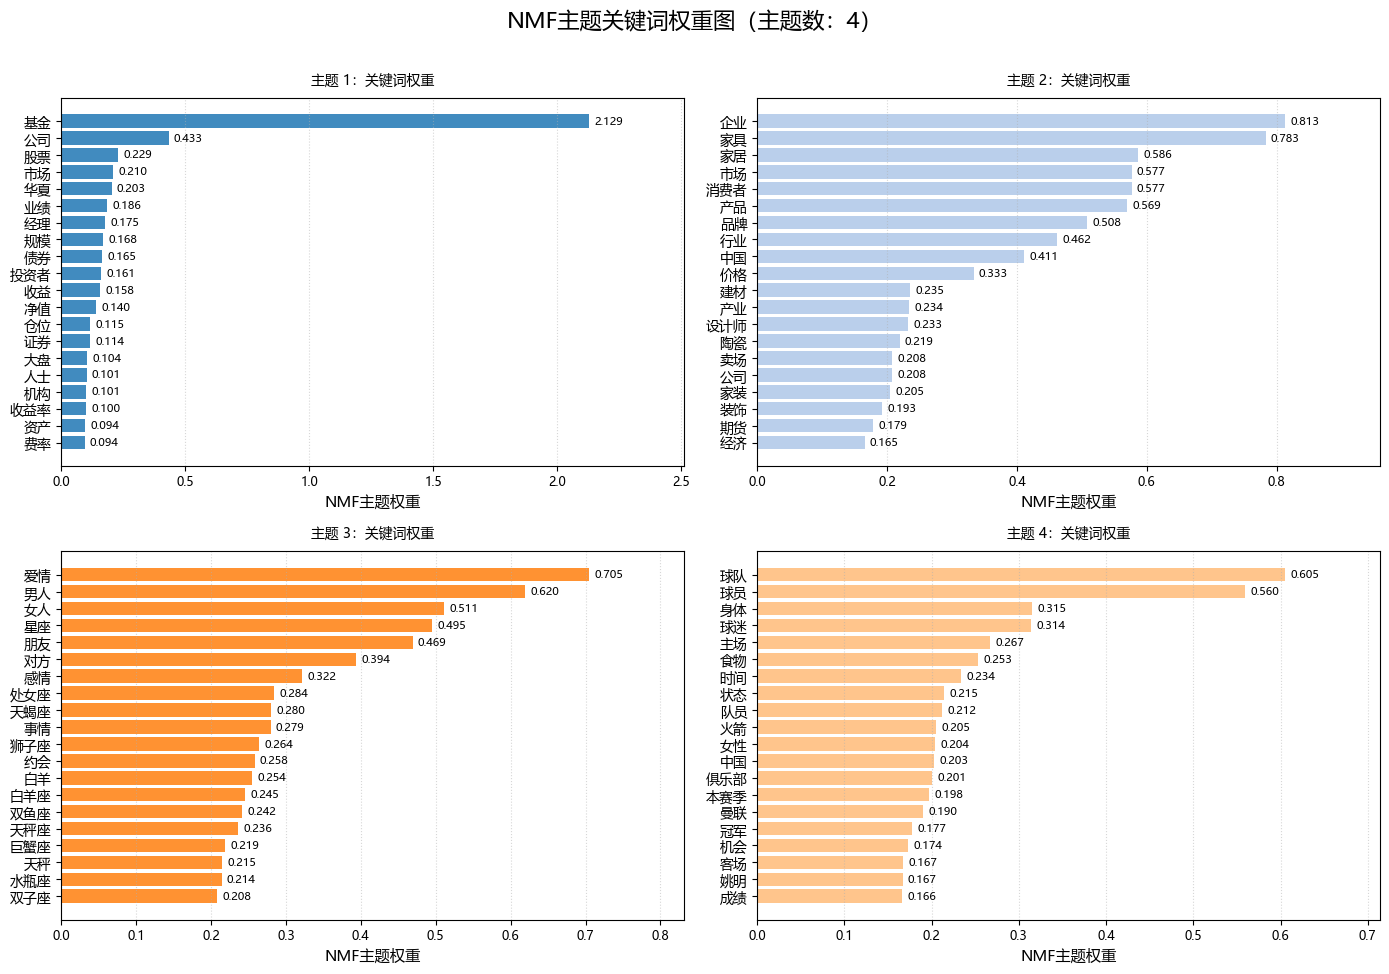

图片保存位置：
C:\temp\nmf_thucnews\NMF主题关键词_K4.png


In [11]:
# -----------------------------------------------------------------------------
# Step 7：绘制NMF主题关键词权重图
# - 从训练好的nmf模型自动读取主题数量
# - 关键词按权重降序排列
# - 最大权重显示在最上方
# - 每个Topic使用不同颜色
# - Topic数量不限制为5个
# -----------------------------------------------------------------------------

import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager


# =============================================================================
# 1. 检查NMF模型是否已经运行
# =============================================================================

if "nmf" not in globals():
    raise RuntimeError(
        "尚未运行NMF模型。请先依次运行Step 2、Step 3、Step 4和Step 5。"
    )

if not hasattr(nmf, "components_"):
    raise RuntimeError(
        "NMF模型尚未完成训练。请先运行Step 5中的nmf.fit_transform(...)。"
    )

if "vectorizer" not in globals():
    raise RuntimeError(
        "尚未建立TF-IDF矩阵。请先运行Step 4。"
    )


# =============================================================================
# 2. 自动取得绘图所需变量
# =============================================================================

# 主题 × 词语权重矩阵
H = nmf.components_

# 特征词
feature_names = vectorizer.get_feature_names_out()

# 自动确定主题数量
N_TOPICS = H.shape[0]

# 如果参数区没有定义，则默认显示前20个关键词
if "N_TOP_WORDS" not in globals():
    N_TOP_WORDS = 20

# 防止关键词数超过词表大小
N_TOP_WORDS = min(
    N_TOP_WORDS,
    len(feature_names)
)

# 如果没有定义输出路径，则使用默认路径
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = r"C:\temp\nmf_thucnews"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("当前主题数量：", N_TOPICS)
print("每个主题显示关键词数：", N_TOP_WORDS)


# =============================================================================
# 3. 屏蔽中文字体警告
# =============================================================================

warnings.filterwarnings(
    "ignore",
    message=r"Glyph .* missing from current font"
)


# =============================================================================
# 4. 设置中文字体
# =============================================================================

font_candidates = [
    r"C:\Windows\Fonts\msyh.ttc",
    r"C:\Windows\Fonts\msyhbd.ttc",
    r"C:\Windows\Fonts\simhei.ttf",
    r"C:\Windows\Fonts\simsun.ttc"
]

chinese_font = None

for font_path in font_candidates:

    if os.path.exists(font_path):

        font_manager.fontManager.addfont(font_path)

        chinese_font = font_manager.FontProperties(
            fname=font_path
        )

        plt.rcParams["font.family"] = (
            chinese_font.get_name()
        )

        break

plt.rcParams["axes.unicode_minus"] = False


# =============================================================================
# 5. 根据主题数量自动设置子图
# =============================================================================

N_COLS = 2

N_ROWS = int(
    np.ceil(N_TOPICS / N_COLS)
)

fig, axes = plt.subplots(
    nrows=N_ROWS,
    ncols=N_COLS,
    figsize=(14, 4.8 * N_ROWS)
)

axes = np.atleast_1d(axes).flatten()


# =============================================================================
# 6. 为不同主题设置不同颜色
# =============================================================================

color_map = plt.colormaps["tab20"]

topic_colors = [
    color_map(i % color_map.N)
    for i in range(N_TOPICS)
]


# =============================================================================
# 7. 绘制各主题关键词权重图
# =============================================================================

for topic_index, topic_weights in enumerate(H):

    # 取得权重最大的关键词，按降序排列
    top_indices = (
        topic_weights
        .argsort()[::-1][:N_TOP_WORDS]
    )

    top_words = feature_names[top_indices]
    top_weights = topic_weights[top_indices]

    ax = axes[topic_index]

    ax.barh(
        top_words,
        top_weights,
        color=topic_colors[topic_index],
        alpha=0.85
    )

    # 最大权重显示在最上方
    ax.invert_yaxis()

    ax.set_title(
        f"主题 {topic_index + 1}：关键词权重",
        fontsize=13,
        fontproperties=chinese_font,
        pad=10
    )

    ax.set_xlabel(
        "NMF主题权重",
        fontsize=11,
        fontproperties=chinese_font
    )

    ax.set_ylabel("")

    # 设置关键词字体
    for label in ax.get_yticklabels():

        if chinese_font is not None:
            label.set_fontproperties(chinese_font)

        label.set_fontsize(10)

    # 设置横坐标字体
    for label in ax.get_xticklabels():

        if chinese_font is not None:
            label.set_fontproperties(chinese_font)

        label.set_fontsize(9)

    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.5
    )

    # 在柱形末端显示权重数值
    max_weight = top_weights.max()

    for position, weight in enumerate(top_weights):

        ax.text(
            weight + max_weight * 0.01,
            position,
            f"{weight:.3f}",
            va="center",
            fontsize=8
        )

    # 给数值标签留出空间
    ax.set_xlim(
        0,
        max_weight * 1.18
    )


# =============================================================================
# 8. 删除未使用的子图
# =============================================================================

for index in range(N_TOPICS, len(axes)):

    fig.delaxes(
        axes[index]
    )


# =============================================================================
# 9. 调整布局并保存
# =============================================================================

fig.suptitle(
    f"NMF主题关键词权重图（主题数：{N_TOPICS}）",
    fontsize=16,
    fontproperties=chinese_font,
    y=1.01
)

plt.tight_layout()

topic_plot_path = os.path.join(
    OUTPUT_DIR,
    f"NMF主题关键词_K{N_TOPICS}.png"
)

plt.savefig(
    topic_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("图片保存位置：")
print(topic_plot_path)

### 每篇文档所属的NMF主题

,文件名,实际类别,模型主题,最高主题权重
0,224237.txt,家居,主题 2,0.0870
1,224519.txt,家居,主题 4,0.0322
2,228865.txt,家居,主题 2,0.2369
3,229138.txt,家居,主题 2,0.0577
4,229204.txt,家居,主题 2,0.1140
5,229264.txt,家居,主题 2,0.1217
6,229317.txt,家居,主题 2,0.1631
7,229373.txt,家居,主题 2,0.1727
8,229676.txt,家居,主题 2,0.1503
9,229810.txt,家居,主题 2,0.1751


### 每个实际类别中的100篇文档被分到哪些NMF主题

模型主题,主题 1,主题 2,主题 3,主题 4,合计
实际类别,,,,,
家居,0,97,0,3,100
星座,0,1,98,1,100
时尚,0,17,10,73,100
体育,0,0,0,100,100
财经,54,43,2,1,100


各文件夹的文档数：
家居：100篇
星座：100篇
时尚：100篇
体育：100篇
财经：100篇
全部文档数： 500


### NMF主题与实际类别的对应关系

,NMF主题,对应的实际类别
0,主题 1,财经
1,主题 2,家居
2,主题 3,星座
3,主题 4,体育


### 实际类别与NMF模型判断类别的对比

,文件名,实际类别,模型主题,模型判断类别,最高主题权重,判断结果
0,224237.txt,家居,主题 2,家居,0.0870,一致
1,224519.txt,家居,主题 4,体育,0.0322,不一致
2,228865.txt,家居,主题 2,家居,0.2369,一致
3,229138.txt,家居,主题 2,家居,0.0577,一致
4,229204.txt,家居,主题 2,家居,0.1140,一致
5,229264.txt,家居,主题 2,家居,0.1217,一致
6,229317.txt,家居,主题 2,家居,0.1631,一致
7,229373.txt,家居,主题 2,家居,0.1727,一致
8,229676.txt,家居,主题 2,家居,0.1503,一致
9,229810.txt,家居,主题 2,家居,0.1751,一致


实际类别与模型判断类别的一致率：69.80%


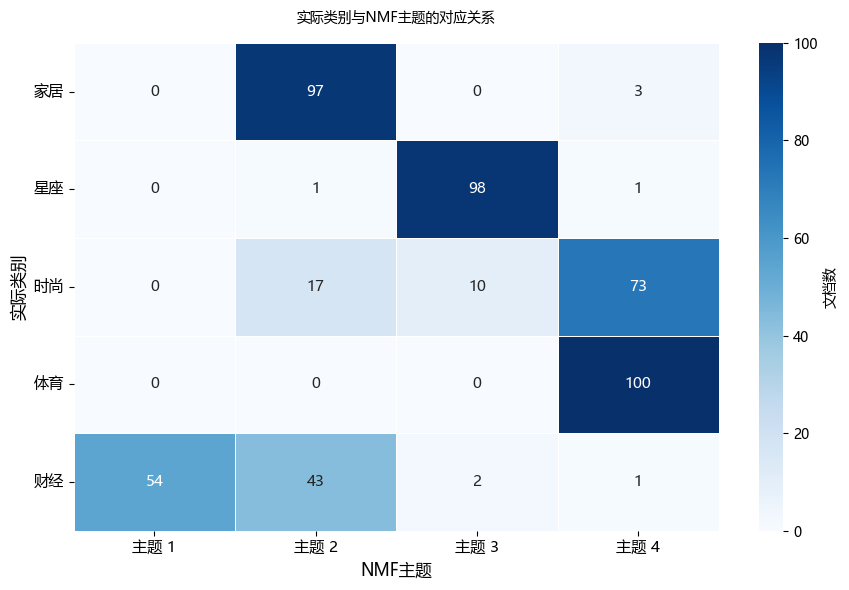

热图保存位置： C:\temp\nmf_thucnews\NMF实际类别与主题热图.png

全部结果已经保存到：
C:\temp\nmf_thucnews


In [12]:
# -----------------------------------------------------------------------------
# NMF Step（9+13）
# 文档主题判断 + 实际类别对比 + 交叉表 + 热图 + 保存结果
# -----------------------------------------------------------------------------

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from matplotlib import font_manager


# =============================================================================
# 0. 中文字体设置
# =============================================================================

warnings.filterwarnings(
    "ignore",
    message=r"Glyph .* missing from current font"
)

font_candidates = [
    r"C:\Windows\Fonts\msyh.ttc",       # 微软雅黑
    r"C:\Windows\Fonts\msyhbd.ttc",     # 微软雅黑粗体
    r"C:\Windows\Fonts\simhei.ttf",     # 黑体
    r"C:\Windows\Fonts\simsun.ttc"      # 宋体
]

chinese_font = None

for font_path in font_candidates:
    if os.path.exists(font_path):

        font_manager.fontManager.addfont(font_path)

        chinese_font = font_manager.FontProperties(
            fname=font_path
        )

        plt.rcParams["font.family"] = chinese_font.get_name()

        break

plt.rcParams["axes.unicode_minus"] = False

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =============================================================================
# 1. 判断每篇文档属于哪个NMF主题
#
# W的每一行表示一篇文档在各主题上的权重。
# 权重最大的主题作为该文档的主要主题。
# =============================================================================

predicted_topic_index = W.argmax(axis=1)

df_documents["模型主题编号"] = predicted_topic_index + 1

df_documents["模型主题"] = [
    f"主题 {topic_index + 1}"
    for topic_index in predicted_topic_index
]

df_documents["最高主题权重"] = W.max(axis=1)


# 添加每个主题的权重
for topic_index in range(N_TOPICS):

    df_documents[f"主题{topic_index + 1}权重"] = (
        W[:, topic_index]
    )


display(Markdown("### 每篇文档所属的NMF主题"))

display(
    df_documents[
        [
            "文件名",
            "实际类别",
            "模型主题",
            "最高主题权重"
        ]
    ]
    .head(20)
    .style.format({
        "最高主题权重": "{:.4f}"
    })
)


# =============================================================================
# 2. 建立“实际类别 × NMF主题”交叉表
#
# 行：原来的文件夹类别
# 列：NMF判断的主题
# =============================================================================

topic_columns = [
    f"主题 {i + 1}"
    for i in range(N_TOPICS)
]

folder_topic_table = pd.crosstab(
    df_documents["实际类别"],
    df_documents["模型主题"]
)

folder_topic_table = folder_topic_table.reindex(
    index=CATEGORIES,
    columns=topic_columns,
    fill_value=0
)


# 增加每行合计
folder_topic_table_with_total = folder_topic_table.copy()

folder_topic_table_with_total["合计"] = (
    folder_topic_table_with_total.sum(axis=1)
)


display(
    Markdown(
        "### 每个实际类别中的100篇文档被分到哪些NMF主题"
    )
)

display(folder_topic_table_with_total)


# 检查各文件夹文档数
print("各文件夹的文档数：")

for category, total in (
    folder_topic_table.sum(axis=1).items()
):
    print(f"{category}：{total}篇")

print(
    "全部文档数：",
    folder_topic_table.to_numpy().sum()
)


# =============================================================================
# 3. 自动建立“NMF主题—实际类别”对应关系
#
# 每个主题中数量最多的实际类别，
# 作为该主题对应的类别名称。
# =============================================================================

topic_to_category = {}

for topic_name in topic_columns:

    category_counts = (
        df_documents.loc[
            df_documents["模型主题"] == topic_name,
            "实际类别"
        ]
        .value_counts()
    )

    if len(category_counts) > 0:

        topic_to_category[topic_name] = (
            category_counts.index[0]
        )

    else:

        topic_to_category[topic_name] = "未分类"


df_topic_mapping = pd.DataFrame({
    "NMF主题": list(topic_to_category.keys()),
    "对应的实际类别": list(topic_to_category.values())
})

display(
    Markdown(
        "### NMF主题与实际类别的对应关系"
    )
)

display(df_topic_mapping)


# =============================================================================
# 4. 实际类别与模型判断类别的对比
# =============================================================================

df_documents["模型判断类别"] = (
    df_documents["模型主题"]
    .map(topic_to_category)
)

df_documents["判断结果"] = np.where(
    df_documents["实际类别"]
    == df_documents["模型判断类别"],
    "一致",
    "不一致"
)

comparison_columns = [
    "文件名",
    "实际类别",
    "模型主题",
    "模型判断类别",
    "最高主题权重",
    "判断结果"
]

df_comparison = (
    df_documents[comparison_columns].copy()
)

display(
    Markdown(
        "### 实际类别与NMF模型判断类别的对比"
    )
)

display(
    df_comparison
    .head(30)
    .style.format({
        "最高主题权重": "{:.4f}"
    })
)


# =============================================================================
# 5. 计算实际类别与模型判断类别的一致率
# =============================================================================

accuracy = (
    df_documents["实际类别"]
    == df_documents["模型判断类别"]
).mean()

print(
    f"实际类别与模型判断类别的一致率："
    f"{accuracy:.2%}"
)


# =============================================================================
# 6. 绘制“实际类别 × NMF主题”热图
# =============================================================================

plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    folder_topic_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "文档数"
    }
)

ax.set_title(
    "实际类别与NMF主题的对应关系",
    fontsize=15,
    pad=15,
    fontproperties=chinese_font
)

ax.set_xlabel(
    "NMF主题",
    fontsize=12,
    fontproperties=chinese_font
)

ax.set_ylabel(
    "实际类别",
    fontsize=12,
    fontproperties=chinese_font
)


# 设置横坐标字体
for label in ax.get_xticklabels():

    label.set_fontproperties(chinese_font)
    label.set_fontsize(11)
    label.set_rotation(0)


# 设置纵坐标字体
for label in ax.get_yticklabels():

    label.set_fontproperties(chinese_font)
    label.set_fontsize(11)
    label.set_rotation(0)


# 设置热图中的数字字体
for text in ax.texts:

    text.set_fontproperties(chinese_font)
    text.set_fontsize(11)


# 设置颜色条字体
colorbar = ax.collections[0].colorbar

if colorbar is not None:

    colorbar.ax.yaxis.label.set_fontproperties(
        chinese_font
    )

    for label in colorbar.ax.get_yticklabels():
        label.set_fontproperties(chinese_font)


plt.tight_layout()


# =============================================================================
# 7. 保存热图
# =============================================================================

heatmap_path = os.path.join(
    OUTPUT_DIR,
    "NMF实际类别与主题热图.png"
)

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("热图保存位置：", heatmap_path)


# =============================================================================
# 8. 保存分析结果
# =============================================================================

# NMF主题关键词
df_topics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "01_NMF主题关键词.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# 实际类别与NMF主题交叉表
folder_topic_table_with_total.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_实际类别与NMF主题交叉表.csv"
    ),
    encoding="utf-8-sig"
)


# NMF主题与类别对应表
df_topic_mapping.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "03_NMF主题与实际类别对应表.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# 每篇文档的主要结果
df_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "04_文档NMF主题判断结果.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# 包含所有主题权重的完整结果
weight_columns = [
    f"主题{i + 1}权重"
    for i in range(N_TOPICS)
]

full_result_columns = [
    "文件名",
    "实际类别",
    "模型主题编号",
    "模型主题",
    "模型判断类别",
    "最高主题权重",
    "判断结果"
] + weight_columns

df_documents[full_result_columns].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "05_文档NMF全部主题权重.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


print("\n全部结果已经保存到：")
print(OUTPUT_DIR)